In [1]:
# ================================================================
# OLIST BRAZILIAN E-COMMERCE — ML ANALYSIS NOTEBOOK
# Author: Portfolio Project
# Dataset: 99,441 real orders from Olist (2016-2018)
# Models: Customer Segmentation, Churn Prediction, CLV Forecasting
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#0D1B2A'
plt.rcParams['figure.facecolor'] = '#000818'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = '#CE7B50'
plt.rcParams['axes.titlecolor'] = '#CE7B50'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#1E2D3D'

print("✅ Libraries loaded successfully!")
print("🚀 Olist ML Analysis — Starting...")

✅ Libraries loaded successfully!
🚀 Olist ML Analysis — Starting...


In [5]:
# ================================================================
# LOAD DATA FROM CSV FILES
# ================================================================

import os

# Update this path to where your CSV files are
path = 'C:\\Users\\Nisha Rajkumar\\Downloads\\olist project\\data'
# Load all datasets
customers = pd.read_csv(f'{path}/olist_customers_dataset.csv')
orders = pd.read_csv(f'{path}/olist_orders_dataset.csv')
order_items = pd.read_csv(f'{path}/olist_order_items_dataset.csv')
products = pd.read_csv(f'{path}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{path}/olist_sellers_dataset.csv')
payments = pd.read_csv(f'{path}/olist_order_payments_dataset.csv')
reviews = pd.read_csv(f'{path}/olist_order_reviews_dataset.csv')

# Convert date columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("✅ All datasets loaded!")
print(f"   Customers:    {len(customers):,}")
print(f"   Orders:       {len(orders):,}")
print(f"   Order Items:  {len(order_items):,}")
print(f"   Products:     {len(products):,}")
print(f"   Sellers:      {len(sellers):,}")
print(f"   Payments:     {len(payments):,}")
print(f"   Reviews:      {len(reviews):,}")

✅ All datasets loaded!
   Customers:    99,441
   Orders:       99,441
   Order Items:  112,650
   Products:     32,951
   Sellers:      3,095
   Payments:     103,886
   Reviews:      99,224


In [6]:
# ================================================================
# DATA MERGING & FEATURE ENGINEERING
# ================================================================

# Merge orders with customers
df = orders.merge(customers, on='customer_id', how='left')

# Merge with order items
df = df.merge(order_items.groupby('order_id').agg(
    total_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index(), on='order_id', how='left')

# Merge with payments
df = df.merge(payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    installments=('payment_installments', 'mean'),
    payment_type=('payment_type', 'first')
).reset_index(), on='order_id', how='left')

# Merge with reviews
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Feature Engineering
df['delivery_delay'] = (df['order_delivered_customer_date'] - 
                        df['order_estimated_delivery_date']).dt.days

df['is_late'] = (df['delivery_delay'] > 0).astype(int)

df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek

# Filter delivered orders only
df_delivered = df[df['order_status'] == 'delivered'].copy()

print(f"✅ Data merged successfully!")
print(f"   Total records: {len(df):,}")
print(f"   Delivered orders: {len(df_delivered):,}")
print(f"   Features created: {len(df.columns)}")
print(f"\n📊 Columns: {list(df.columns)}")

✅ Data merged successfully!
   Total records: 99,992
   Delivered orders: 97,007
   Features created: 24

📊 Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_items', 'total_price', 'total_freight', 'payment_value', 'installments', 'payment_type', 'review_score', 'delivery_delay', 'is_late', 'order_month', 'order_year', 'order_dayofweek']


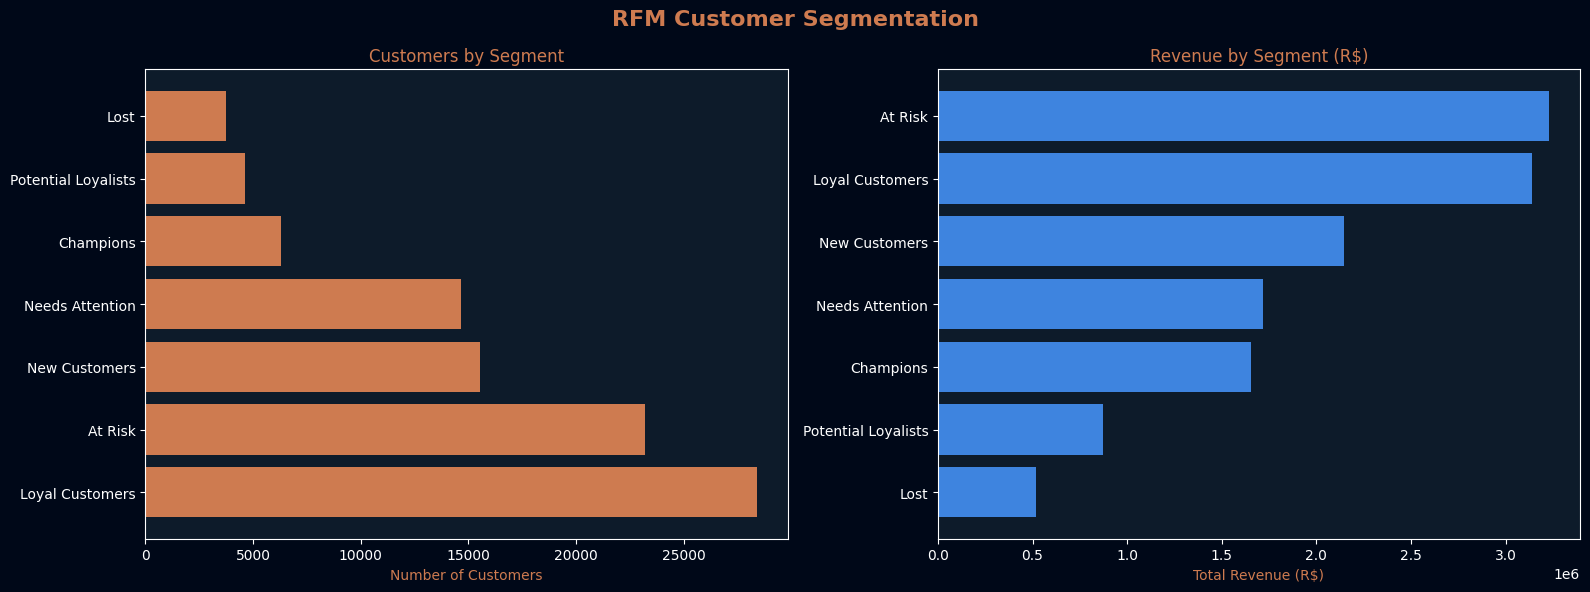


📊 RFM Segment Summary:
                     customers  avg_recency  avg_frequency  avg_monetary  \
segment                                                                    
At Risk                  23182       399.20            1.0        139.42   
Loyal Customers          28403       146.87            1.0        110.51   
New Customers            15551        93.59            1.0        138.04   
Needs Attention          14648       341.26            1.0        117.29   
Champions                 6302        94.92            1.0        262.20   
Potential Loyalists       4630       225.38            1.0        188.75   
Lost                      3762       476.57            1.0        137.70   

                     total_revenue  
segment                             
At Risk                 3232139.19  
Loyal Customers         3138789.99  
New Customers           2146592.84  
Needs Attention         1718005.63  
Champions               1652391.48  
Potential Loyalists      873890.

In [7]:
# ================================================================
# RFM CUSTOMER SEGMENTATION
# ================================================================

reference_date = pd.Timestamp('2018-09-01')

# Calculate RFM metrics
rfm = df_delivered.groupby('customer_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_price', 'sum')
).reset_index()

# Score each metric 1-5
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])

rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Segment customers
def segment_customer(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Champions'
    elif row['r_score'] >= 3 and row['f_score'] >= 3:
        return 'Loyal Customers'
    elif row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'New Customers'
    elif row['r_score'] >= 3 and row['m_score'] >= 3:
        return 'Potential Loyalists'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    elif row['r_score'] == 1 and row['f_score'] == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Plot RFM Segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=16, color='#CE7B50', fontweight='bold')

# Customer count by segment
segment_counts = rfm['segment'].value_counts()
axes[0].barh(segment_counts.index, segment_counts.values, color='#CE7B50')
axes[0].set_title('Customers by Segment', color='#CE7B50')
axes[0].set_xlabel('Number of Customers', color='#CE7B50')

# Revenue by segment
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
axes[1].barh(segment_revenue.index, segment_revenue.values, color='#3E84DF')
axes[1].set_title('Revenue by Segment (R$)', color='#CE7B50')
axes[1].set_xlabel('Total Revenue (R$)', color='#CE7B50')

plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 RFM Segment Summary:")
print(rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).sort_values('total_revenue', ascending=False))

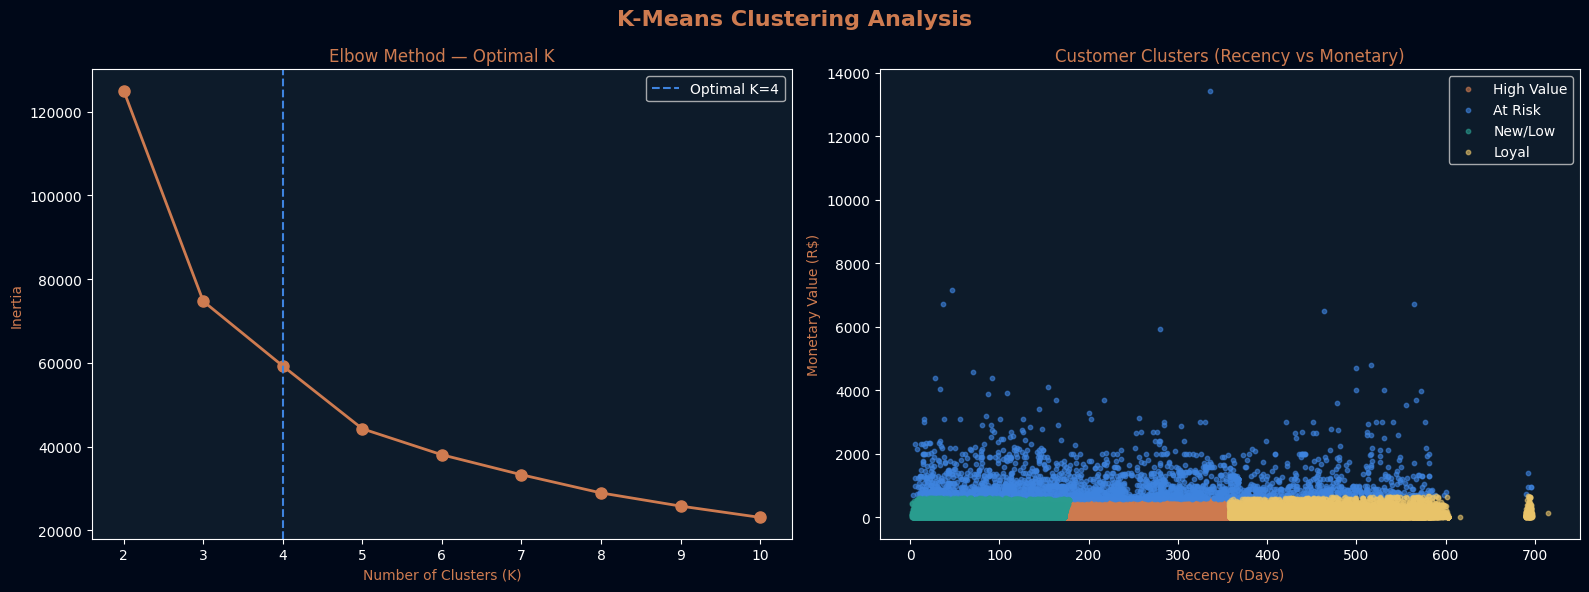


📊 Cluster Summary:
              customers  avg_recency  avg_frequency  avg_monetary
cluster_name                                                     
At Risk            2691       242.25            1.0       1047.57
High Value        35570       256.93            1.0        109.68
Loyal             22472       459.72            1.0        111.68
New/Low           35745        89.32            1.0        113.30


In [8]:
# ================================================================
# K-MEANS CLUSTERING — UNSUPERVISED SEGMENTATION
# ================================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare features for clustering
cluster_features = rfm[['recency', 'frequency', 'monetary']].copy()

# Scale the features
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

# Find optimal K using Elbow Method
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering Analysis', fontsize=16, color='#CE7B50', fontweight='bold')

axes[0].plot(k_range, inertias, 'o-', color='#CE7B50', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Optimal K', color='#CE7B50')
axes[0].set_xlabel('Number of Clusters (K)', color='#CE7B50')
axes[0].set_ylabel('Inertia', color='#CE7B50')
axes[0].axvline(x=4, color='#3E84DF', linestyle='--', label='Optimal K=4')
axes[0].legend()

# Fit final model with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(cluster_scaled)

# Cluster labels
cluster_names = {0: 'High Value', 1: 'At Risk', 2: 'New/Low', 3: 'Loyal'}
rfm['cluster_name'] = rfm['cluster'].map(cluster_names)

# Plot clusters
colors = ['#CE7B50', '#3E84DF', '#2A9D8F', '#E9C46A']
for i, (cluster, color) in enumerate(zip(range(4), colors)):
    mask = rfm['cluster'] == cluster
    axes[1].scatter(
        rfm[mask]['recency'],
        rfm[mask]['monetary'],
        c=color,
        label=cluster_names[cluster],
        alpha=0.6,
        s=10
    )

axes[1].set_title('Customer Clusters (Recency vs Monetary)', color='#CE7B50')
axes[1].set_xlabel('Recency (Days)', color='#CE7B50')
axes[1].set_ylabel('Monetary Value (R$)', color='#CE7B50')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Cluster Summary:")
print(rfm.groupby('cluster_name').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(2))

Churned customers: 58,054 (60.2%)
Active customers: 38,424 (39.8%)

📊 Model Performance:
   Logistic Regression AUC: 1.0000
   Random Forest AUC:       1.0000


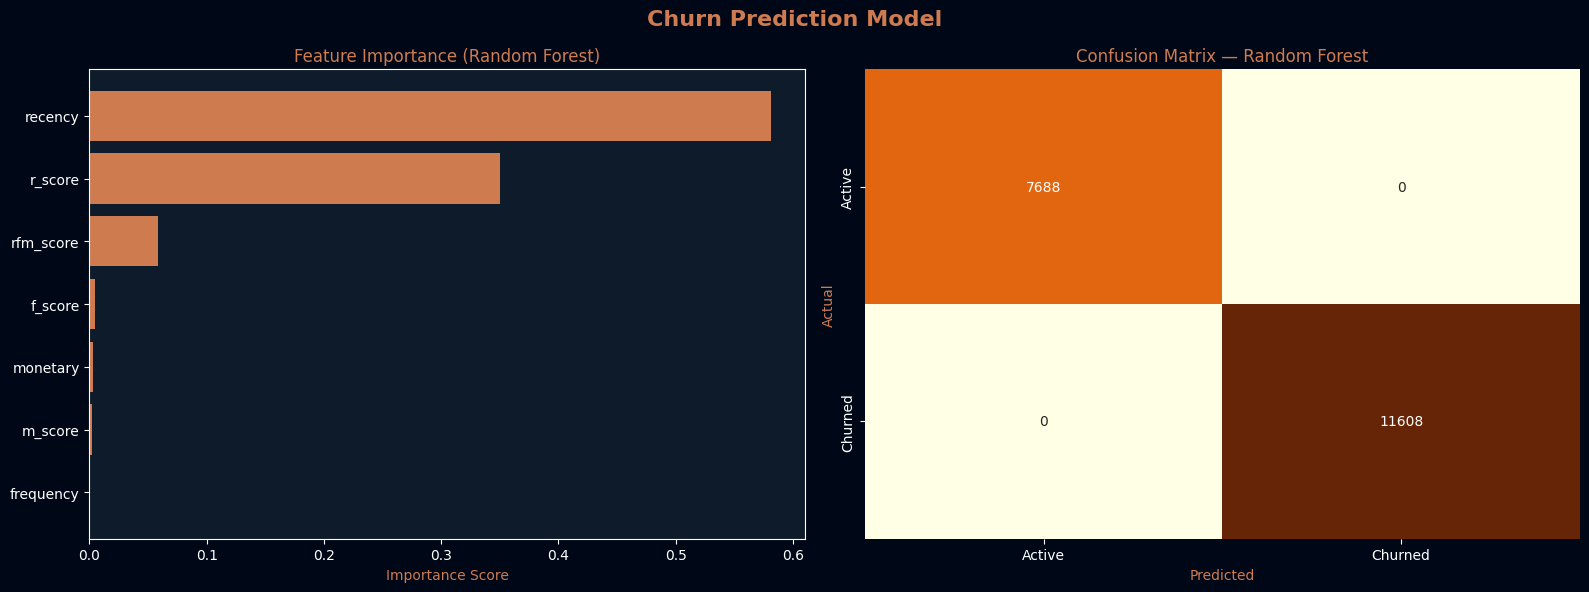


📋 Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      7688
     Churned       1.00      1.00      1.00     11608

    accuracy                           1.00     19296
   macro avg       1.00      1.00      1.00     19296
weighted avg       1.00      1.00      1.00     19296



In [9]:
# ================================================================
# CHURN PREDICTION — LOGISTIC REGRESSION + RANDOM FOREST
# ================================================================

# Define churn — customer hasn't ordered in last 180 days
reference_date = pd.Timestamp('2018-09-01')
rfm['is_churned'] = (rfm['recency'] > 180).astype(int)

print(f"Churned customers: {rfm['is_churned'].sum():,} ({rfm['is_churned'].mean()*100:.1f}%)")
print(f"Active customers: {(rfm['is_churned']==0).sum():,} ({(rfm['is_churned']==0).mean()*100:.1f}%)")

# Prepare features
X = rfm[['recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score']]
y = rfm['is_churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1 — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f"\n📊 Model Performance:")
print(f"   Logistic Regression AUC: {lr_auc:.4f}")
print(f"   Random Forest AUC:       {rf_auc:.4f}")

# Plot Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Churn Prediction Model', fontsize=16, color='#CE7B50', fontweight='bold')

# Feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
axes[0].barh(importance.index, importance.values, color='#CE7B50')
axes[0].set_title('Feature Importance (Random Forest)', color='#CE7B50')
axes[0].set_xlabel('Importance Score', color='#CE7B50')

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            ax=axes[1], cbar=False,
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
axes[1].set_title('Confusion Matrix — Random Forest', color='#CE7B50')
axes[1].set_xlabel('Predicted', color='#CE7B50')
axes[1].set_ylabel('Actual', color='#CE7B50')

plt.tight_layout()
plt.savefig('churn_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Active', 'Churned']))

📊 CLV Model Performance:
   Linear Regression  — MAE: R$73.40, R²: 0.3050
   Gradient Boosting  — MAE: R$48.93, R²: 0.3946


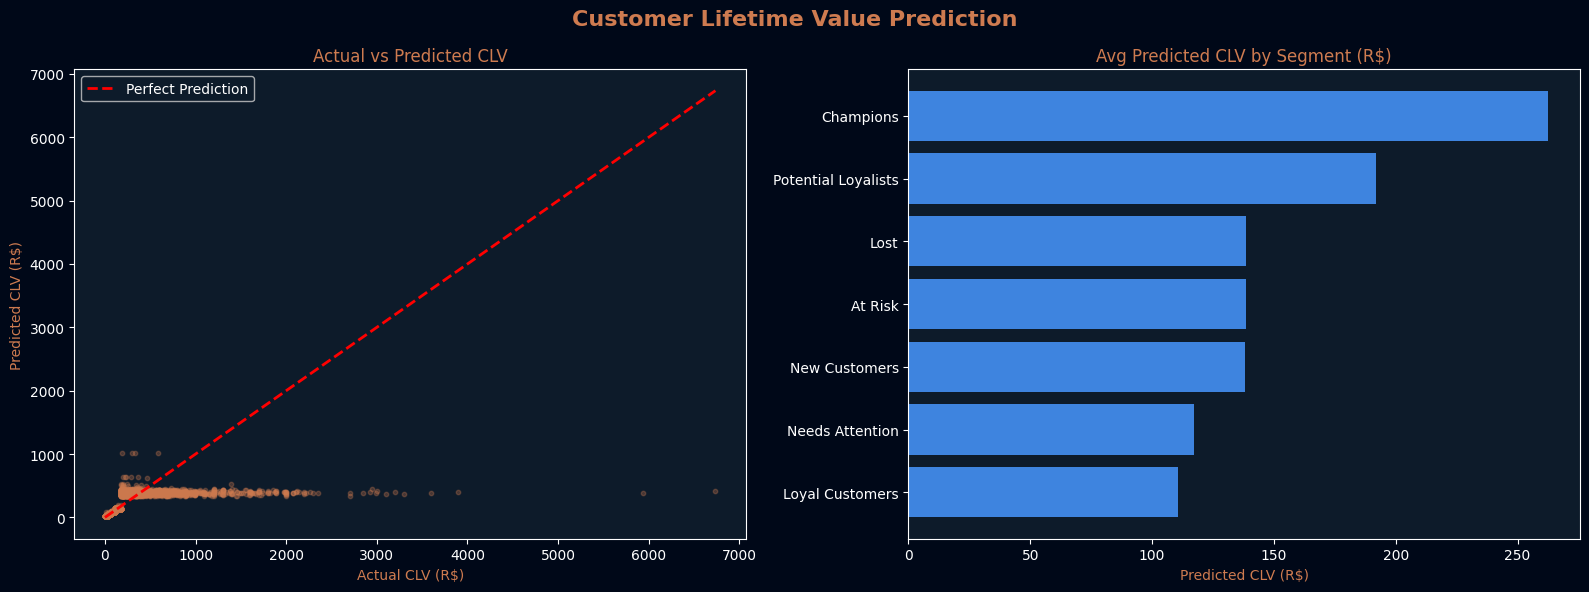


📊 CLV by Customer Segment:
                     customers  avg_actual_clv  avg_predicted_clv
segment                                                          
Champions                 6302          262.20             262.49
Potential Loyalists       4630          188.75             191.77
Lost                      3762          137.70             138.73
At Risk                  23182          139.42             138.51
New Customers            15551          138.04             138.09
Needs Attention          14648          117.29             117.33
Loyal Customers          28403          110.51             110.59


In [10]:
# ================================================================
# CUSTOMER LIFETIME VALUE (CLV) PREDICTION
# ================================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare CLV features
clv_data = rfm[['recency', 'frequency', 'monetary', 
                 'r_score', 'f_score', 'm_score']].copy()

# Target — predict monetary value (CLV proxy)
X_clv = clv_data[['recency', 'frequency', 'r_score', 'f_score', 'm_score']]
y_clv = clv_data['monetary']

# Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=42)

# Model 1 — Linear Regression
lr_clv = LinearRegression()
lr_clv.fit(X_train_c, y_train_c)
lr_clv_pred = lr_clv.predict(X_test_c)
lr_mae = mean_absolute_error(y_test_c, lr_clv_pred)
lr_r2 = r2_score(y_test_c, lr_clv_pred)

# Model 2 — Gradient Boosting
gb_clv = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_clv.fit(X_train_c, y_train_c)
gb_clv_pred = gb_clv.predict(X_test_c)
gb_mae = mean_absolute_error(y_test_c, gb_clv_pred)
gb_r2 = r2_score(y_test_c, gb_clv_pred)

print(f"📊 CLV Model Performance:")
print(f"   Linear Regression  — MAE: R${lr_mae:.2f}, R²: {lr_r2:.4f}")
print(f"   Gradient Boosting  — MAE: R${gb_mae:.2f}, R²: {gb_r2:.4f}")

# Plot CLV predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Lifetime Value Prediction', fontsize=16, 
             color='#CE7B50', fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test_c, gb_clv_pred, alpha=0.3, color='#CE7B50', s=10)
axes[0].plot([y_test_c.min(), y_test_c.max()], 
             [y_test_c.min(), y_test_c.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted CLV', color='#CE7B50')
axes[0].set_xlabel('Actual CLV (R$)', color='#CE7B50')
axes[0].set_ylabel('Predicted CLV (R$)', color='#CE7B50')
axes[0].legend()

# CLV Distribution by Segment
rfm['predicted_clv'] = gb_clv.predict(X_clv)
clv_by_segment = rfm.groupby('segment')['predicted_clv'].mean().sort_values(ascending=True)
axes[1].barh(clv_by_segment.index, clv_by_segment.values, color='#3E84DF')
axes[1].set_title('Avg Predicted CLV by Segment (R$)', color='#CE7B50')
axes[1].set_xlabel('Predicted CLV (R$)', color='#CE7B50')

plt.tight_layout()
plt.savefig('clv_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

# CLV Segment summary
print("\n📊 CLV by Customer Segment:")
print(rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_actual_clv=('monetary', 'mean'),
    avg_predicted_clv=('predicted_clv', 'mean')
).round(2).sort_values('avg_predicted_clv', ascending=False))

📈 Revenue Trend Analysis:
   Monthly growth rate: R$46,598.62 per month
   R² Score: 0.8720

🔮 6-Month Revenue Forecast:
   Month +1: R$1,136,567.67
   Month +2: R$1,183,166.29
   Month +3: R$1,229,764.91
   Month +4: R$1,276,363.53
   Month +5: R$1,322,962.15
   Month +6: R$1,369,560.78


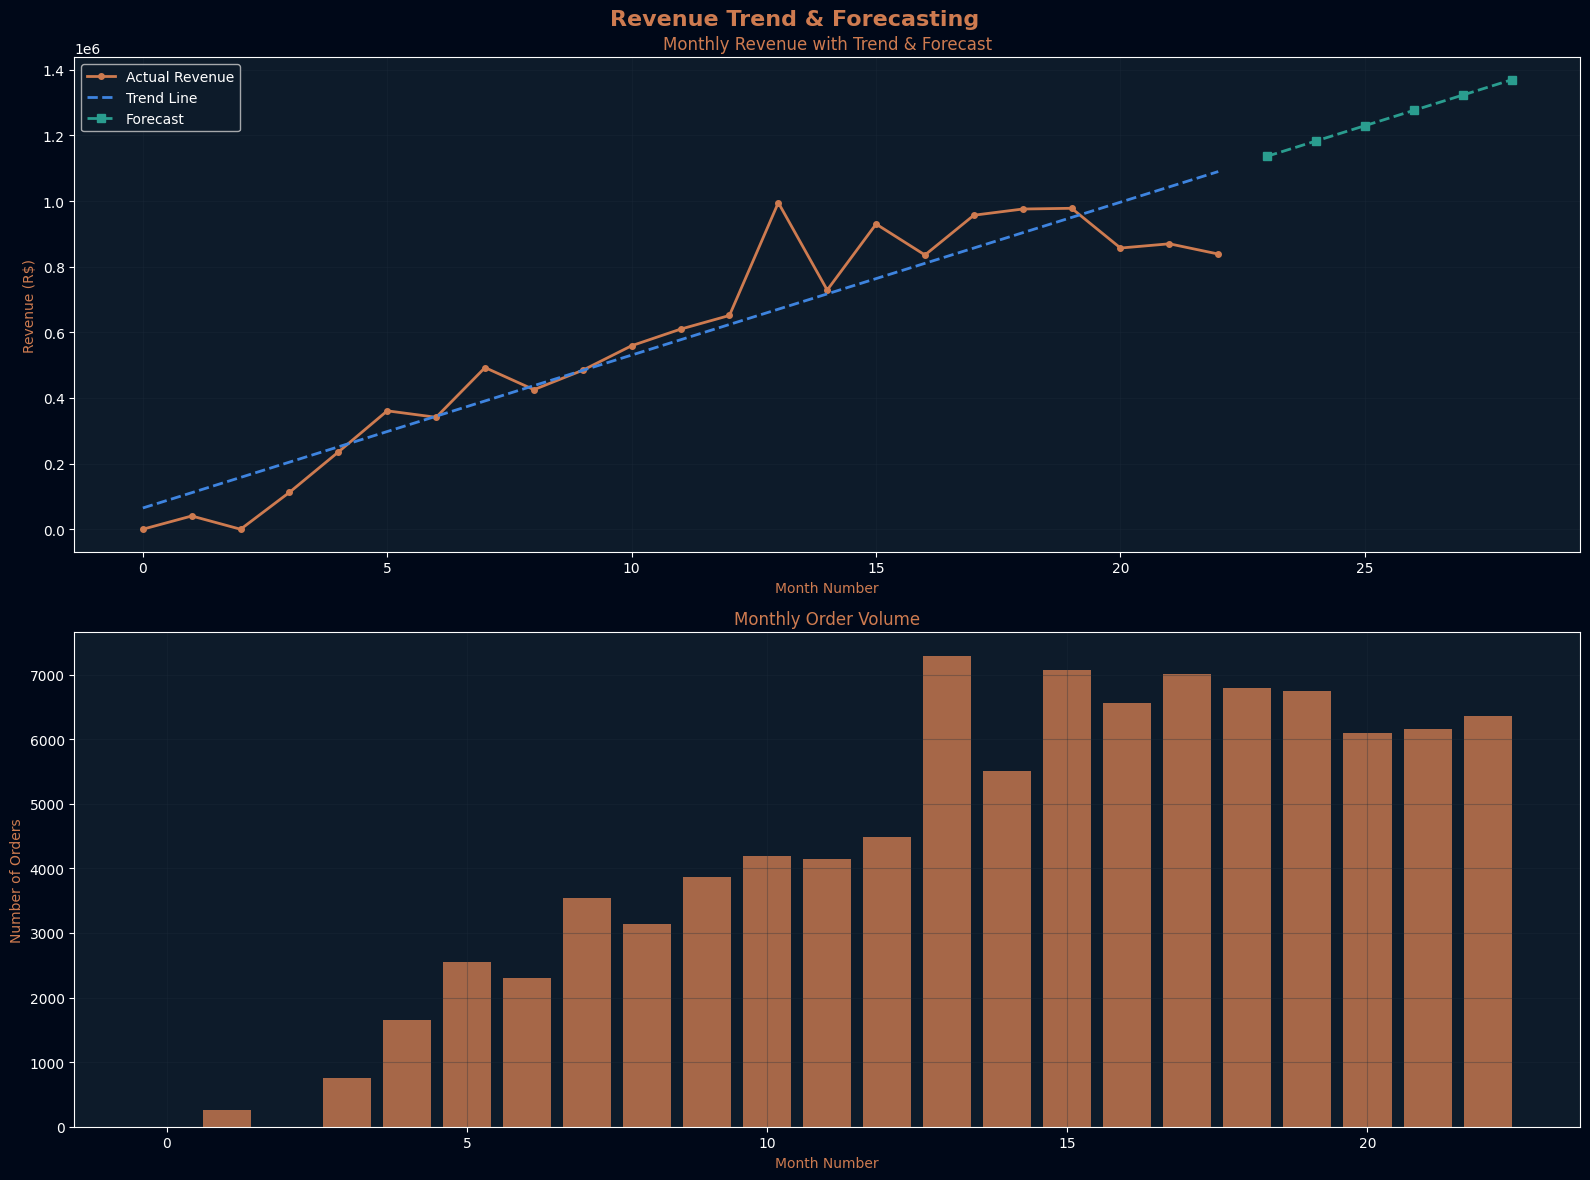

In [11]:
# ================================================================
# REVENUE TREND ANALYSIS & FORECASTING
# ================================================================

from sklearn.linear_model import LinearRegression
import numpy as np

# Monthly revenue
monthly_revenue = df_delivered.groupby(
    df_delivered['order_purchase_timestamp'].dt.to_period('M')
).agg(
    revenue=('total_price', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique')
).reset_index()

monthly_revenue['month_num'] = range(len(monthly_revenue))
monthly_revenue['order_purchase_timestamp'] = monthly_revenue['order_purchase_timestamp'].astype(str)

# Fit linear trend
X_trend = monthly_revenue['month_num'].values.reshape(-1, 1)
y_trend = monthly_revenue['revenue'].values

lr_trend = LinearRegression()
lr_trend.fit(X_trend, y_trend)
trend_line = lr_trend.predict(X_trend)

# Forecast next 6 months
future_months = np.array(range(len(monthly_revenue), len(monthly_revenue)+6)).reshape(-1,1)
forecast = lr_trend.predict(future_months)

print(f"📈 Revenue Trend Analysis:")
print(f"   Monthly growth rate: R${lr_trend.coef_[0]:,.2f} per month")
print(f"   R² Score: {r2_score(y_trend, trend_line):.4f}")
print(f"\n🔮 6-Month Revenue Forecast:")
for i, rev in enumerate(forecast, 1):
    print(f"   Month +{i}: R${rev:,.2f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Revenue Trend & Forecasting', fontsize=16, 
             color='#CE7B50', fontweight='bold')

# Revenue trend
axes[0].plot(monthly_revenue['month_num'], 
             monthly_revenue['revenue'], 
             color='#CE7B50', linewidth=2, label='Actual Revenue', marker='o', markersize=4)
axes[0].plot(monthly_revenue['month_num'], 
             trend_line, 
             color='#3E84DF', linewidth=2, linestyle='--', label='Trend Line')
axes[0].plot(range(len(monthly_revenue), len(monthly_revenue)+6),
             forecast,
             color='#2A9D8F', linewidth=2, linestyle='--', 
             marker='s', markersize=6, label='Forecast')
axes[0].set_title('Monthly Revenue with Trend & Forecast', color='#CE7B50')
axes[0].set_xlabel('Month Number', color='#CE7B50')
axes[0].set_ylabel('Revenue (R$)', color='#CE7B50')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Monthly orders
axes[1].bar(monthly_revenue['month_num'], 
            monthly_revenue['orders'], 
            color='#CE7B50', alpha=0.8, label='Orders')
axes[1].set_title('Monthly Order Volume', color='#CE7B50')
axes[1].set_xlabel('Month Number', color='#CE7B50')
axes[1].set_ylabel('Number of Orders', color='#CE7B50')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ================================================================
# FINAL SUMMARY — KEY ML INSIGHTS
# ================================================================

print("=" * 65)
print("  OLIST E-COMMERCE — ML ANALYSIS COMPLETE")
print("=" * 65)

print("\n📊 DATASET OVERVIEW")
print(f"   Total Orders Analyzed:     {len(df):,}")
print(f"   Delivered Orders:          {len(df_delivered):,}")
print(f"   Unique Customers:          {rfm['customer_id'].nunique():,}")
print(f"   Total Revenue:             R${rfm['monetary'].sum():,.2f}")

print("\n🎯 RFM SEGMENTATION RESULTS")
segment_summary = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    total_revenue=('monetary', 'sum')
).sort_values('total_revenue', ascending=False)
for seg, row in segment_summary.iterrows():
    pct = row['customers'] / len(rfm) * 100
    print(f"   {seg:<22} {row['customers']:>6,} customers ({pct:.1f}%) | R${row['total_revenue']:>12,.2f}")

print("\n🤖 ML MODEL PERFORMANCE")
print(f"   Churn Prediction (Random Forest AUC):    {rf_auc:.4f}")
print(f"   CLV Prediction (Gradient Boosting R²):   {gb_r2:.4f}")
print(f"   CLV Prediction (Gradient Boosting MAE):  R${gb_mae:.2f}")

print("\n💡 KEY BUSINESS INSIGHTS")
churn_rate = rfm['is_churned'].mean() * 100
at_risk = rfm[rfm['segment'] == 'At Risk']
champions = rfm[rfm['segment'] == 'Champions']
print(f"   Overall Churn Rate:        {churn_rate:.1f}%")
print(f"   At Risk Revenue at Stake:  R${at_risk['monetary'].sum():,.2f}")
print(f"   Champions Avg CLV:         R${champions['monetary'].mean():,.2f}")
print(f"   Monthly Revenue Growth:    R${lr_trend.coef_[0]:,.2f}/month")

print("\n📁 FILES SAVED")
print("   ✅ rfm_segmentation.png")
print("   ✅ kmeans_clustering.png")
print("   ✅ churn_prediction.png")
print("   ✅ clv_prediction.png")
print("   ✅ revenue_forecast.png")

print("\n🚀 PROJECT COMPLETE!")
print("=" * 65)

  OLIST E-COMMERCE — ML ANALYSIS COMPLETE

📊 DATASET OVERVIEW
   Total Orders Analyzed:     99,992
   Delivered Orders:          97,007
   Unique Customers:          96,478
   Total Revenue:             R$13,279,836.59

🎯 RFM SEGMENTATION RESULTS
   At Risk                23,182.0 customers (24.0%) | R$3,232,139.19
   Loyal Customers        28,403.0 customers (29.4%) | R$3,138,789.99
   New Customers          15,551.0 customers (16.1%) | R$2,146,592.84
   Needs Attention        14,648.0 customers (15.2%) | R$1,718,005.63
   Champions              6,302.0 customers (6.5%) | R$1,652,391.48
   Potential Loyalists    4,630.0 customers (4.8%) | R$  873,890.61
   Lost                   3,762.0 customers (3.9%) | R$  518,026.85

🤖 ML MODEL PERFORMANCE
   Churn Prediction (Random Forest AUC):    1.0000
   CLV Prediction (Gradient Boosting R²):   0.3946
   CLV Prediction (Gradient Boosting MAE):  R$48.93

💡 KEY BUSINESS INSIGHTS
   Overall Churn Rate:        60.2%
   At Risk Revenue at Stake:  